# Notebook 2 | Predicción de `Severity Level` y `Attack Type`

## Objetivo

En este segundo notebook se amplía el trabajo realizado en el notebook principal sobre `Action Taken`.

En lugar de repetir toda la exploración inicial, se reutiliza la lógica de preprocesado y feature engineering ya validada previamente, aplicándola ahora a los otros dos targets del dataset:

- **`Severity Level`**
- **`Attack Type`**

Además, este notebook permitirá comparar qué variable objetivo resulta más predecible con las features disponibles y servirá como espacio para experimentos adicionales de modelado.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

df = pd.read_csv("./data/cybersecurity_attacks.csv")
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,IoC Detected,28.6700,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,IoC Detected,51.5000,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,IoC Detected,87.4200,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,NaN,15.7900,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,NaN,0.5200,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


## Nota sobre la metodología

Las decisiones principales de limpieza y preprocesado ya fueron justificadas en el notebook 1.  
Por ello, en este notebook se reutiliza una versión mejorada del pipeline, evitando repetir toda la fase exploratoria inicial.

En concreto, se aplicarán las siguientes ideas ya validadas:

- transformación de `Timestamp` en variables temporales,
- creación de variables semánticas sobre puertos,
- binarización de algunas columnas con muchos nulos,
- exclusión de variables de cardinalidad extrema o difícil generalización,
- codificación automática de variables categóricas dentro del pipeline.

In [2]:
df_model = df.copy()
df_model.columns.tolist()

['Timestamp',
 'Source IP Address',
 'Destination IP Address',
 'Source Port',
 'Destination Port',
 'Protocol',
 'Packet Length',
 'Packet Type',
 'Traffic Type',
 'Payload Data',
 'Malware Indicators',
 'Anomaly Scores',
 'Alerts/Warnings',
 'Attack Type',
 'Attack Signature',
 'Action Taken',
 'Severity Level',
 'User Information',
 'Device Information',
 'Network Segment',
 'Geo-location Data',
 'Proxy Information',
 'Firewall Logs',
 'IDS/IPS Alerts',
 'Log Source']

In [3]:
for col in ["Action Taken", "Severity Level", "Attack Type"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Action Taken =====
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

===== Severity Level =====
Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

===== Attack Type =====
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


In [4]:
# =========================================================
# Construcción del dataset mejorado reutilizable
# =========================================================

df_model = df.copy()

# Timestamp -> datetime
df_model["Timestamp"] = pd.to_datetime(df_model["Timestamp"], errors="coerce")

# Features temporales
df_model["hour"] = df_model["Timestamp"].dt.hour
df_model["day"] = df_model["Timestamp"].dt.day
df_model["month"] = df_model["Timestamp"].dt.month
df_model["dayofweek"] = df_model["Timestamp"].dt.dayofweek
df_model["is_weekend"] = df_model["dayofweek"].isin([5, 6]).astype(int)

def get_part_of_day(hour):
    if pd.isna(hour):
        return "unknown"
    hour = int(hour)
    if 0 <= hour < 6:
        return "madrugada"
    elif 6 <= hour < 12:
        return "mañana"
    elif 12 <= hour < 18:
        return "tarde"
    else:
        return "noche"

df_model["part_of_day"] = df_model["hour"].apply(get_part_of_day)

# Ingeniería de puertos
def port_range(port):
    if pd.isna(port):
        return "unknown"
    port = int(port)
    if port < 1024:
        return "well_known"
    elif port <= 49151:
        return "registered"
    else:
        return "dynamic"

df_model["Source Port Range"] = df_model["Source Port"].apply(port_range)
df_model["Destination Port Range"] = df_model["Destination Port"].apply(port_range)

COMMON_DEST_PORTS = {80, 443, 22, 21, 25, 53, 3389}

def destination_port_group(port):
    if pd.isna(port):
        return "unknown"
    port = int(port)
    return str(port) if port in COMMON_DEST_PORTS else "other"

df_model["Destination Port Group"] = df_model["Destination Port"].apply(destination_port_group)

# Columnas con muchos nulos -> presencia/ausencia
BINARY_COLS = [
    "Malware Indicators",
    "Alerts/Warnings",
    "Firewall Logs",
    "IDS/IPS Alerts",
    "Proxy Information",
]

for col in BINARY_COLS:
    df_model[col + "_present"] = df_model[col].notna().astype(int)

# Columnas a eliminar
DROP_COLS = [
    "Source IP Address",
    "Destination IP Address",
    "Payload Data",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Timestamp",
    *BINARY_COLS
]

df_model = df_model.drop(columns=DROP_COLS)

print("Shape del dataset modelable:", df_model.shape)
df_model.head()

Shape del dataset modelable: (40000, 27)


,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Anomaly Scores,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Log Source,hour,day,month,dayofweek,is_weekend,part_of_day,Source Port Range,Destination Port Range,Destination Port Group,Malware Indicators_present,Alerts/Warnings_present,Firewall Logs_present,IDS/IPS Alerts_present,Proxy Information_present
0,31225,17616,ICMP,503,Data,HTTP,28.6700,Malware,Known Pattern B,Logged,Low,Segment A,Server,6,30,5,1,0,mañana,registered,registered,other,1,0,1,0,1
1,17245,48166,ICMP,1174,Data,HTTP,51.5000,Malware,Known Pattern A,Blocked,Low,Segment B,Firewall,7,26,8,2,0,mañana,registered,registered,other,1,0,1,0,0
2,16811,53600,UDP,306,Control,HTTP,87.4200,DDoS,Known Pattern B,Ignored,Low,Segment C,Firewall,8,13,11,6,1,mañana,registered,dynamic,other,1,1,1,1,1
3,20018,32534,UDP,385,Data,HTTP,15.7900,Malware,Known Pattern B,Blocked,Medium,Segment B,Firewall,10,2,7,6,1,mañana,registered,registered,other,0,1,0,1,0
4,6131,26646,TCP,1462,Data,DNS,0.5200,DDoS,Known Pattern B,Blocked,Low,Segment C,Firewall,13,16,7,6,1,tarde,registered,registered,other,0,1,0,1,1


In [5]:
def evaluate_target(df_variant, target_name, random_state=RANDOM_STATE):
    """
    Evalúa varios modelos sobre un target multiclase.
    Excluye automáticamente los otros dos targets.
    """

    all_targets = ["Action Taken", "Severity Level", "Attack Type"]
    other_targets = [t for t in all_targets if t != target_name]

    X = df_variant.drop(columns=other_targets + [target_name])
    y = df_variant[target_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    num_cols_local = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_local = X_train.select_dtypes(include=["object"]).columns.tolist()

    preprocessor_scaled = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    preprocessor_passthrough = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    models = {
        "Dummy": (
            DummyClassifier(strategy="most_frequent", random_state=random_state),
            preprocessor_passthrough
        ),
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=random_state),
            preprocessor_scaled
        ),
        "Logistic Regression Balanced": (
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state),
            preprocessor_scaled
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
        "ExtraTrees": (
            ExtraTreesClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
    }

    results = []
    trained_pipelines = {}

    for name, (clf, prep) in models.items():
        pipe = Pipeline([
            ("preprocessor", prep),
            ("classifier", clf),
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X_test)
                roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
            except Exception:
                pass

        results.append({
            "target": target_name,
            "model": name,
            "accuracy": round(acc, 4),
            "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4),
            "f1_macro": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4),
            "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
        })

        trained_pipelines[name] = pipe

    df_results = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

    return df_results, trained_pipelines, X_train, X_test, y_train, y_test

## Escenario A | Predicción de `Severity Level`

En este primer escenario se reutiliza el pipeline mejorado para predecir la variable `Severity Level`.
Se excluyen del conjunto de entrada los otros dos targets (`Action Taken` y `Attack Type`) para evitar leakage.

In [6]:
df_results_severity, trained_severity, X_train_sev, X_test_sev, y_train_sev, y_test_sev = evaluate_target(
    df_model,
    target_name="Severity Level"
)

df_results_severity

,target,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,Severity Level,Logistic Regression,0.3415,0.3410,0.3412,0.3405,0.3412,0.5028
1,Severity Level,Logistic Regression Balanced,0.3399,0.3406,0.3401,0.3394,0.3401,0.5027
2,Severity Level,Gradient Boosting,0.3387,0.3383,0.3384,0.3363,0.3384,0.4979
3,Severity Level,ExtraTrees,0.3357,0.3356,0.3357,0.3355,0.3357,0.5044
4,Severity Level,Random Forest,0.3317,0.3315,0.3316,0.3314,0.3316,0.5001
5,Severity Level,Dummy,0.3359,0.1120,0.3333,0.1676,0.3333,0.5000


In [7]:
best_model_severity = df_results_severity.iloc[0]["model"]
best_pipe_severity = trained_severity[best_model_severity]
y_pred_severity = best_pipe_severity.predict(X_test_sev)

print("Mejor modelo para Severity Level:", best_model_severity)
print("\nClassification report:\n")
print(classification_report(y_test_sev, y_pred_severity, zero_division=0))

Mejor modelo para Severity Level: Logistic Regression

Classification report:

              precision    recall  f1-score   support

        High       0.34      0.36      0.35      2676
         Low       0.33      0.29      0.31      2637
      Medium       0.35      0.37      0.36      2687

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



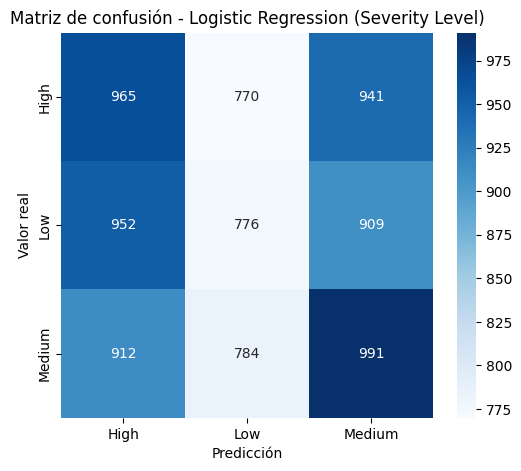

In [8]:
cm_severity = confusion_matrix(y_test_sev, y_pred_severity, labels=best_pipe_severity.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_severity,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_pipe_severity.classes_,
    yticklabels=best_pipe_severity.classes_
)
plt.title(f"Matriz de confusión - {best_model_severity} (Severity Level)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Escenario B | Predicción de `Attack Type`

En este segundo escenario se aplica la misma lógica de preprocesado y modelado para predecir `Attack Type`.
De nuevo, se excluyen del conjunto de entrada los otros dos targets para mantener la coherencia metodológica.

In [9]:
df_results_attack, trained_attack, X_train_att, X_test_att, y_train_att, y_test_att = evaluate_target(
    df_model,
    target_name="Attack Type"
)

df_results_attack

,target,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,Attack Type,Random Forest,0.3414,0.3414,0.3413,0.3410,0.3413,0.5069
1,Attack Type,Logistic Regression Balanced,0.3385,0.3386,0.3386,0.3383,0.3386,0.5043
2,Attack Type,Gradient Boosting,0.3374,0.3373,0.3373,0.3373,0.3373,0.5063
3,Attack Type,Logistic Regression,0.3375,0.3373,0.3373,0.3367,0.3373,0.5043
4,Attack Type,ExtraTrees,0.3282,0.3283,0.3282,0.3281,0.3282,0.4973
5,Attack Type,Dummy,0.3357,0.1119,0.3333,0.1676,0.3333,0.5000


In [10]:
best_model_attack = df_results_attack.iloc[0]["model"]
best_pipe_attack = trained_attack[best_model_attack]
y_pred_attack = best_pipe_attack.predict(X_test_att)

print("Mejor modelo para Attack Type:", best_model_attack)
print("\nClassification report:\n")
print(classification_report(y_test_att, y_pred_attack, zero_division=0))

Mejor modelo para Attack Type: Random Forest

Classification report:

              precision    recall  f1-score   support

        DDoS       0.34      0.37      0.35      2686
   Intrusion       0.34      0.35      0.34      2653
     Malware       0.34      0.31      0.33      2661

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



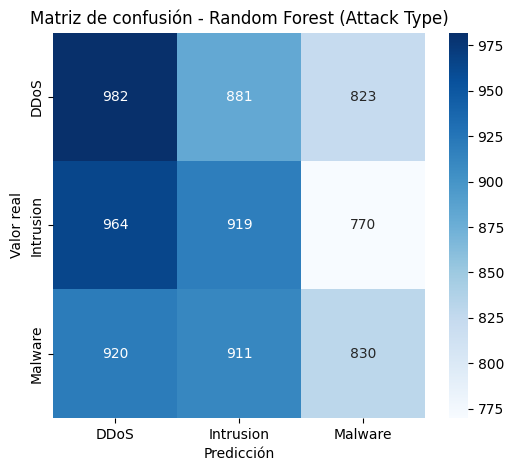

In [11]:
cm_attack = confusion_matrix(y_test_att, y_pred_attack, labels=best_pipe_attack.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_attack,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_pipe_attack.classes_,
    yticklabels=best_pipe_attack.classes_
)
plt.title(f"Matriz de confusión - {best_model_attack} (Attack Type)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Comparación global entre targets

Una vez entrenados los modelos para `Severity Level` y `Attack Type`, se comparan sus mejores resultados con los obtenidos previamente en `Action Taken`.

Esto permite observar qué variable objetivo resulta más predecible con las features disponibles en el dataset.

In [12]:
comparison_targets = pd.DataFrame([
    {
        "target": "Action Taken",
        "mejor_modelo": "XGBoost",
        "f1_macro": 0.3403,
        "accuracy": 0.3425,
        "balanced_accuracy": 0.3419
    },
    {
        "target": "Severity Level",
        "mejor_modelo": df_results_severity.iloc[0]["model"],
        "f1_macro": df_results_severity.iloc[0]["f1_macro"],
        "accuracy": df_results_severity.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_severity.iloc[0]["balanced_accuracy"]
    },
    {
        "target": "Attack Type",
        "mejor_modelo": df_results_attack.iloc[0]["model"],
        "f1_macro": df_results_attack.iloc[0]["f1_macro"],
        "accuracy": df_results_attack.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_attack.iloc[0]["balanced_accuracy"]
    }
])

comparison_targets

,target,mejor_modelo,f1_macro,accuracy,balanced_accuracy
0,Action Taken,XGBoost,0.3403,0.3425,0.3419
1,Severity Level,Logistic Regression,0.3405,0.3415,0.3412
2,Attack Type,Random Forest,0.3410,0.3414,0.3413


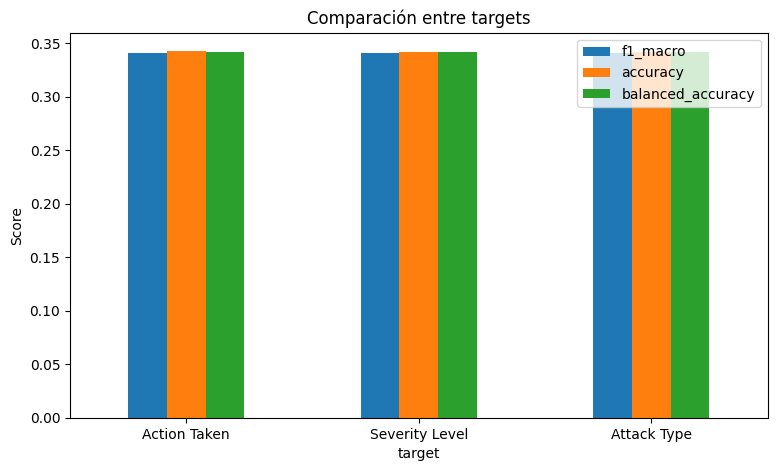

In [13]:
comparison_targets.set_index("target")[["f1_macro", "accuracy", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Comparación entre targets")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Interpretación de la comparativa entre targets

Los tres targets obtienen resultados prácticamente idénticos, con F1 macro entre 0.340 y 0.341.
Ninguno resulta significativamente más predecible que los demás con las features disponibles.

Esto refuerza la hipótesis planteada en el notebook 1: la señal predictiva del dataset es
limitada de forma generalizada, independientemente del target que se intente predecir.
La ausencia de diferencia entre targets sugiere que los tres han sido asignados de forma
igualmente aleatoria respecto a las variables de red disponibles.

## Nueva fase de experimentación

En este notebook se ha reutilizado la lógica de preprocesado desarrollada para `Action Taken` con el fin de estudiar los otros dos targets del dataset: `Severity Level` y `Attack Type`.

La comparación entre resultados permitirá determinar:

- si estos targets son más predecibles que `Action Taken`,
- si el pipeline actual generaliza razonablemente a distintos objetivos,
- y qué dirección conviene tomar en los experimentos adicionales.

En una fase posterior se podrán añadir pruebas complementarias, como:
- versiones binarias del problema,
- análisis de importancia de variables,
- o experimentos con variables de texto como `Payload Data`.

## Importancia de variables

Como ampliación del análisis, se estudia qué variables están aportando más señal predictiva en los mejores modelos obtenidos para cada target.

Esto permite interpretar mejor el comportamiento del pipeline y detectar si algunas variables están siendo especialmente relevantes o si, por el contrario, otras podrían estar introduciendo ruido.

In [14]:
def get_feature_importance_from_pipeline(pipe, top_n=20):
    """
    Extrae importancias de variables desde un Pipeline con:
    - preprocessor (ColumnTransformer)
    - classifier con feature_importances_
    """
    clf = pipe.named_steps["classifier"]
    preprocessor = pipe.named_steps["preprocessor"]

    if not hasattr(clf, "feature_importances_"):
        raise ValueError("El clasificador no tiene atributo feature_importances_")

    feature_names = preprocessor.get_feature_names_out()
    importances = clf.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return importance_df.head(top_n), importance_df

In [15]:
# Intentamos usar el mejor modelo de árbol disponible para Severity Level
tree_candidates_sev = ["Random Forest", "Gradient Boosting", "ExtraTrees"]

selected_tree_model_sev = None
for m in tree_candidates_sev:
    if m in trained_severity:
        selected_tree_model_sev = m
        break

selected_tree_model_sev

'Random Forest'

,feature,importance
0,num__Anomaly Scores,0.0961
1,num__Destination Port,0.0956
2,num__Source Port,0.0954
3,num__Packet Length,0.0951
4,num__day,0.0782
5,num__hour,0.0656
6,num__month,0.0617
7,num__dayofweek,0.0461
8,num__Alerts/Warnings_present,0.0192
9,num__Firewall Logs_present,0.0188


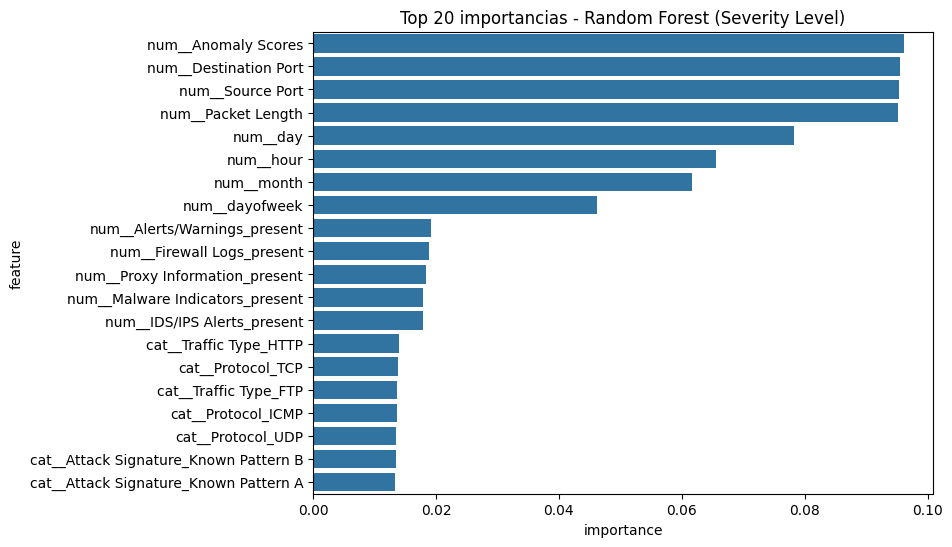

In [16]:
if selected_tree_model_sev is not None:
    top_imp_sev, full_imp_sev = get_feature_importance_from_pipeline(
        trained_severity[selected_tree_model_sev],
        top_n=20
    )
    display(top_imp_sev)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=top_imp_sev, x="importance", y="feature")
    plt.title(f"Top 20 importancias - {selected_tree_model_sev} (Severity Level)")
    plt.show()
else:
    print("No hay modelo de árbol disponible para Severity Level.")

In [17]:
tree_candidates_att = ["Random Forest", "Gradient Boosting", "ExtraTrees"]

selected_tree_model_att = None
for m in tree_candidates_att:
    if m in trained_attack:
        selected_tree_model_att = m
        break

selected_tree_model_att

'Random Forest'

,feature,importance
0,num__Source Port,0.0967
1,num__Anomaly Scores,0.0966
2,num__Destination Port,0.0964
3,num__Packet Length,0.0962
4,num__day,0.0778
5,num__hour,0.0664
6,num__month,0.0607
7,num__dayofweek,0.0471
8,num__Malware Indicators_present,0.0188
9,num__IDS/IPS Alerts_present,0.0185


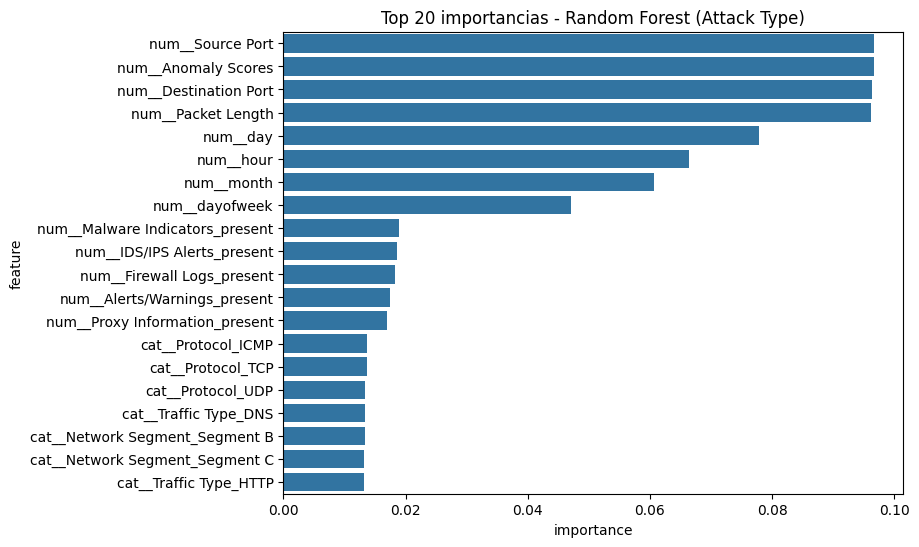

In [18]:
if selected_tree_model_att is not None:
    top_imp_att, full_imp_att = get_feature_importance_from_pipeline(
        trained_attack[selected_tree_model_att],
        top_n=20
    )
    display(top_imp_att)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=top_imp_att, x="importance", y="feature")
    plt.title(f"Top 20 importancias - {selected_tree_model_att} (Attack Type)")
    plt.show()
else:
    print("No hay modelo de árbol disponible para Attack Type.")

### Interpretación de las importancias

Este análisis permite comprobar si variables como los puertos, la firma del ataque, las variables temporales o los indicadores binarios están aportando realmente señal al modelo.

También puede servir para detectar variables con peso muy bajo, candidatas a ser eliminadas en futuras iteraciones, o variables con gran protagonismo que justifiquen nuevas transformaciones.

### Interpretación de las importancias para Attack Type

El patrón es prácticamente idéntico al observado para `Severity Level`.Las cuatro numéricas continuas lideran el ranking con importancias entre 0.096
y 0.097: `Source Port`, `Anomaly Scores`, `Destination Port` y `Packet Length`.

Las variables temporales siguen con `day` (0.078), `hour` (0.066) y `month` (0.061). Los indicadores binarios contribuyen de forma similar (~0.017–0.019) y las categóricas
encoded cierran el ranking con valores de ~0.013.

La similitud entre los rankings de `Severity Level` y `Attack Type` refuerza la hipótesis de que el dataset no tiene una estructura diferenciada por target:
los mismos predictores con los mismos pesos aparecen en ambos casos.
En un dataset con señal real, esperaríamos que distintos targets fueran sensibles a distintas variables. Aquí no ocurre.

## Reformulación binaria de los targets

Como parte del laboratorio, se exploran versiones binarias de algunos targets para comprobar si el dataset
permite separar mejor ciertas clases concretas frente al resto.

En muchos problemas, una formulación multiclase puede resultar difícil, mientras que una variante binaria
sí permite capturar señal útil de forma más clara.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

def evaluate_binary_target(df_variant, original_target, positive_class, random_state=RANDOM_STATE):
    """
    Convierte un target multiclase en binario:
    positive_class vs resto
    """

    all_targets = ["Action Taken", "Severity Level", "Attack Type"]
    other_targets = [t for t in all_targets if t != original_target]

    X = df_variant.drop(columns=other_targets + [original_target])
    y = (df_variant[original_target] == positive_class).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    num_cols_local = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_local = X_train.select_dtypes(include=["object"]).columns.tolist()

    preprocessor_scaled = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    preprocessor_passthrough = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    models = {
        "Dummy": (
            DummyClassifier(strategy="most_frequent", random_state=random_state),
            preprocessor_passthrough
        ),
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=random_state),
            preprocessor_scaled
        ),
        "Logistic Regression Balanced": (
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state),
            preprocessor_scaled
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
        "ExtraTrees": (
            ExtraTreesClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
    }

    results = []
    trained_pipelines = {}

    for name, (clf, prep) in models.items():
        pipe = Pipeline([
            ("preprocessor", prep),
            ("classifier", clf),
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_proba)
            except Exception:
                pass

        results.append({
            "target": f"{original_target} | {positive_class} vs resto",
            "model": name,
            "accuracy": round(acc, 4),
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4),
            "roc_auc": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
        })

        trained_pipelines[name] = pipe

    df_results = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)

    return df_results, trained_pipelines, X_train, X_test, y_train, y_test

## Experimento binario A `Action Taken`: `Blocked` vs resto

En este experimento se transforma `Action Taken` en un problema binario, donde la clase positiva es `Blocked`
y todas las demás (`Ignored`, `Logged`) se agrupan como clase negativa.

El objetivo es comprobar si esta formulación simplificada permite capturar mejor la señal del dataset.

In [20]:
df_results_blocked, trained_blocked, X_train_blocked, X_test_blocked, y_train_blocked, y_test_blocked = evaluate_binary_target(
    df_model,
    original_target="Action Taken",
    positive_class="Blocked"
)

df_results_blocked

,target,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,Action Taken | Blocked vs resto,Logistic Regression Balanced,0.5156,0.3523,0.5152,0.4184,0.5155,0.5105
1,Action Taken | Blocked vs resto,ExtraTrees,0.6499,0.3401,0.0373,0.0673,0.5002,0.4946
2,Action Taken | Blocked vs resto,Random Forest,0.6574,0.1930,0.0041,0.0080,0.4977,0.5007
3,Action Taken | Blocked vs resto,Gradient Boosting,0.6616,0.4615,0.0022,0.0044,0.5004,0.5039
4,Action Taken | Blocked vs resto,Dummy,0.6617,0.0000,0.0000,0.0000,0.5000,0.5000
5,Action Taken | Blocked vs resto,Logistic Regression,0.6617,0.0000,0.0000,0.0000,0.5000,0.5106


In [21]:
best_model_blocked = df_results_blocked.iloc[0]["model"]
best_pipe_blocked = trained_blocked[best_model_blocked]
y_pred_blocked = best_pipe_blocked.predict(X_test_blocked)

print("Mejor modelo para Blocked vs resto:", best_model_blocked)
print("\nClassification report:\n")
print(classification_report(y_test_blocked, y_pred_blocked, zero_division=0))

Mejor modelo para Blocked vs resto: Logistic Regression Balanced

Classification report:

              precision    recall  f1-score   support

           0       0.68      0.52      0.58      5294
           1       0.35      0.52      0.42      2706

    accuracy                           0.52      8000
   macro avg       0.51      0.52      0.50      8000
weighted avg       0.57      0.52      0.53      8000



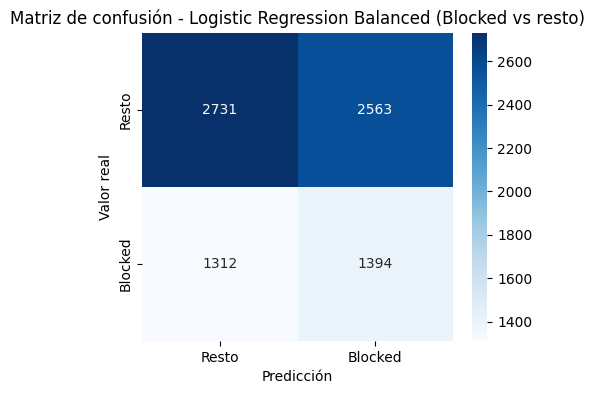

In [22]:
cm_blocked = confusion_matrix(y_test_blocked, y_pred_blocked)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_blocked, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Resto", "Blocked"],
            yticklabels=["Resto", "Blocked"])
plt.title(f"Matriz de confusión - {best_model_blocked} (Blocked vs resto)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Experimento binario B `Severity Level`: `High` vs resto

En este experimento se transforma `Severity Level` en un problema binario, donde la clase positiva es `High`
y las clases `Low` y `Medium` se agrupan como clase negativa.

Esto permite analizar si el dataset identifica mejor los eventos de severidad alta que la clasificación multiclase completa.

In [23]:
df_results_high, trained_high, X_train_high, X_test_high, y_train_high, y_test_high = evaluate_binary_target(
    df_model,
    original_target="Severity Level",
    positive_class="High"
)

df_results_high

,target,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,Severity Level | High vs resto,Logistic Regression Balanced,0.5069,0.3403,0.5052,0.4067,0.5065,0.5032
1,Severity Level | High vs resto,ExtraTrees,0.6551,0.3707,0.0445,0.0794,0.5033,0.4951
2,Severity Level | High vs resto,Random Forest,0.6630,0.3684,0.0105,0.0203,0.5007,0.5055
3,Severity Level | High vs resto,Gradient Boosting,0.6659,0.6154,0.0030,0.0060,0.5010,0.4939
4,Severity Level | High vs resto,Dummy,0.6655,0.0000,0.0000,0.0000,0.5000,0.5000
5,Severity Level | High vs resto,Logistic Regression,0.6655,0.0000,0.0000,0.0000,0.5000,0.5036


In [24]:
best_model_high = df_results_high.iloc[0]["model"]
best_pipe_high = trained_high[best_model_high]
y_pred_high = best_pipe_high.predict(X_test_high)

print("Mejor modelo para High vs resto:", best_model_high)
print("\nClassification report:\n")
print(classification_report(y_test_high, y_pred_high, zero_division=0))

Mejor modelo para High vs resto: Logistic Regression Balanced

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.51      0.58      5324
           1       0.34      0.51      0.41      2676

    accuracy                           0.51      8000
   macro avg       0.51      0.51      0.49      8000
weighted avg       0.56      0.51      0.52      8000



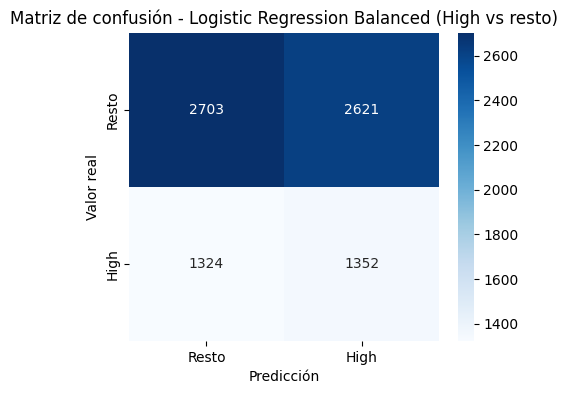

In [25]:
cm_high = confusion_matrix(y_test_high, y_pred_high)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_high, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Resto", "High"],
            yticklabels=["Resto", "High"])
plt.title(f"Matriz de confusión - {best_model_high} (High vs resto)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Comparación de experimentos binarios

Se comparan ahora los mejores resultados de las reformulaciones binarias para comprobar si la simplificación
del problema permite mejorar el rendimiento respecto a la clasificación multiclase.

In [26]:
comparison_binary = pd.DataFrame([
    {
        "experimento": "Blocked vs resto",
        "mejor_modelo": df_results_blocked.iloc[0]["model"],
        "f1": df_results_blocked.iloc[0]["f1"],
        "accuracy": df_results_blocked.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_blocked.iloc[0]["balanced_accuracy"],
        "roc_auc": df_results_blocked.iloc[0]["roc_auc"]
    },
    {
        "experimento": "High vs resto",
        "mejor_modelo": df_results_high.iloc[0]["model"],
        "f1": df_results_high.iloc[0]["f1"],
        "accuracy": df_results_high.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_high.iloc[0]["balanced_accuracy"],
        "roc_auc": df_results_high.iloc[0]["roc_auc"]
    }
])

comparison_binary

,experimento,mejor_modelo,f1,accuracy,balanced_accuracy,roc_auc
0,Blocked vs resto,Logistic Regression Balanced,0.4184,0.5156,0.5155,0.5105
1,High vs resto,Logistic Regression Balanced,0.4067,0.5069,0.5065,0.5032


## Interpretación de los experimentos binarios

La reformulación binaria mejora el F1 respecto a la clasificación multiclase:`Logistic Regression Balanced` alcanza F1 de 0.418 en "Blocked vs resto"
y 0.407 en "High vs resto", frente al ~0.33 de la versión multiclase.

Sin embargo, hay que interpretar esto con cautela. Los modelos sin balance (Random Forest, Gradient Boosting, LR estándar) obtienen accuracy de ~0.66
pero F1 cercano a cero — están prediciendo siempre la clase mayoritaria (resto) y aciertan por pura proporción. Solo `LR Balanced` consigue un equilibrio real
entre precision y recall sobre la clase positiva.

La mejora en F1 binario no indica que haya más señal en el dataset, sino que al reducir el problema a dos clases, `LR Balanced` puede recuperar una fracción
mayor de la clase minoritaria aunque la separabilidad siga siendo limitada.

## Experimento ordinal / regresión sobre `Severity Level`

La variable `Severity Level` presenta una estructura ordenada natural:

- `Low`
- `Medium`
- `High`

Por ello, además de tratarla como un problema de clasificación multiclase, se explora una formulación alternativa como problema ordinal simplificado.

En este experimento se codifica la severidad como:

- `Low = 0`
- `Medium = 1`
- `High = 2`

y se entrenan varios modelos de regresión.  
Posteriormente, las predicciones continuas se redondean y se vuelven a convertir a etiquetas categóricas para poder compararlas con el enfoque de clasificación.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_ordinal_regression_severity(df_variant, random_state=RANDOM_STATE):
    """
    Trata Severity Level como variable ordinal:
    Low=0, Medium=1, High=2
    Entrena varios regresores y convierte sus predicciones de nuevo a clases.
    """

    severity_map = {"Low": 0, "Medium": 1, "High": 2}
    inverse_map = {0: "Low", 1: "Medium", 2: "High"}

    all_targets = ["Action Taken", "Severity Level", "Attack Type"]
    X = df_variant.drop(columns=all_targets)
    y = df_variant["Severity Level"].map(severity_map)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    num_cols_local = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_local = X_train.select_dtypes(include=["object"]).columns.tolist()

    preprocessor_scaled = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    preprocessor_passthrough = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    regressors = {
        "Linear Regression": (
            LinearRegression(),
            preprocessor_scaled
        ),
        "Random Forest Regressor": (
            RandomForestRegressor(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
        "Gradient Boosting Regressor": (
            GradientBoostingRegressor(n_estimators=100, random_state=random_state),
            preprocessor_passthrough
        ),
    }

    results = []
    trained_pipelines = {}

    for name, (reg, prep) in regressors.items():
        pipe = Pipeline([
            ("preprocessor", prep),
            ("regressor", reg),
        ])

        pipe.fit(X_train, y_train)
        y_pred_cont = pipe.predict(X_test)

        # recortar a rango válido y redondear
        y_pred_ord = np.clip(np.rint(y_pred_cont), 0, 2).astype(int)

        # métricas de regresión
        mae = mean_absolute_error(y_test, y_pred_cont)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_cont))

        # métricas de clasificación tras discretizar
        acc = accuracy_score(y_test, y_pred_ord)
        prec = precision_score(y_test, y_pred_ord, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred_ord, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred_ord, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred_ord)

        results.append({
            "target": "Severity Level (ordinal/regresión)",
            "model": name,
            "mae": round(mae, 4),
            "rmse": round(rmse, 4),
            "accuracy": round(acc, 4),
            "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4),
            "f1_macro": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4)
        })

        trained_pipelines[name] = pipe

    df_results = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

    return df_results, trained_pipelines, X_train, X_test, y_train, y_test, inverse_map

In [28]:
df_results_severity_reg, trained_severity_reg, X_train_sev_reg, X_test_sev_reg, y_train_sev_reg, y_test_sev_reg, inverse_map_sev = evaluate_ordinal_regression_severity(
    df_model
)

df_results_severity_reg

,target,model,mae,rmse,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy
0,Severity Level (ordinal/regresión),Gradient Boosting Regressor,0.6736,0.8162,0.3360,0.2073,0.3335,0.1682,0.3335
1,Severity Level (ordinal/regresión),Linear Regression,0.6708,0.8152,0.3359,0.1120,0.3333,0.1676,0.3333
2,Severity Level (ordinal/regresión),Random Forest Regressor,0.6949,0.8234,0.3359,0.1120,0.3333,0.1676,0.3333


In [29]:
best_model_sev_reg = df_results_severity_reg.iloc[0]["model"]
best_pipe_sev_reg = trained_severity_reg[best_model_sev_reg]

y_pred_cont_sev_reg = best_pipe_sev_reg.predict(X_test_sev_reg)
y_pred_ord_sev_reg = np.clip(np.rint(y_pred_cont_sev_reg), 0, 2).astype(int)

print("Mejor modelo ordinal/regresión para Severity Level:", best_model_sev_reg)
print("\nClassification report:\n")
print(classification_report(y_test_sev_reg, y_pred_ord_sev_reg, zero_division=0))

Mejor modelo ordinal/regresión para Severity Level: Gradient Boosting Regressor

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2637
           1       0.34      1.00      0.50      2687
           2       0.29      0.00      0.00      2676

    accuracy                           0.34      8000
   macro avg       0.21      0.33      0.17      8000
weighted avg       0.21      0.34      0.17      8000



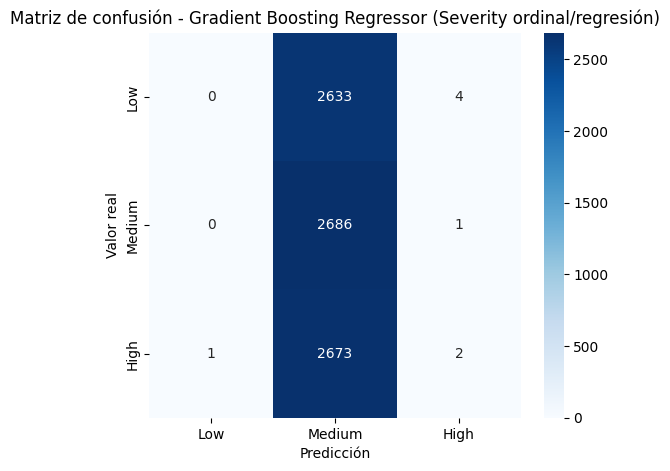

In [30]:
cm_sev_reg = confusion_matrix(y_test_sev_reg, y_pred_ord_sev_reg, labels=[0, 1, 2])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_sev_reg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title(f"Matriz de confusión - {best_model_sev_reg} (Severity ordinal/regresión)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Comparación entre clasificación multiclase y formulación ordinal

Una vez evaluada la severidad como problema ordinal/regresión, se compara el mejor resultado de este enfoque con el mejor resultado obtenido previamente mediante clasificación multiclase estándar.

Esto permite comprobar si la estructura ordenada de `Severity Level` resulta útil o no desde el punto de vista del modelado.

In [31]:
comparison_severity_modes = pd.DataFrame([
    {
        "enfoque": "Clasificación multiclase",
        "mejor_modelo": df_results_severity.iloc[0]["model"],
        "f1_macro": df_results_severity.iloc[0]["f1_macro"],
        "accuracy": df_results_severity.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_severity.iloc[0]["balanced_accuracy"]
    },
    {
        "enfoque": "Ordinal / regresión",
        "mejor_modelo": df_results_severity_reg.iloc[0]["model"],
        "f1_macro": df_results_severity_reg.iloc[0]["f1_macro"],
        "accuracy": df_results_severity_reg.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_severity_reg.iloc[0]["balanced_accuracy"]
    }
])

comparison_severity_modes

,enfoque,mejor_modelo,f1_macro,accuracy,balanced_accuracy
0,Clasificación multiclase,Logistic Regression,0.3405,0.3415,0.3412
1,Ordinal / regresión,Gradient Boosting Regressor,0.1682,0.3360,0.3335


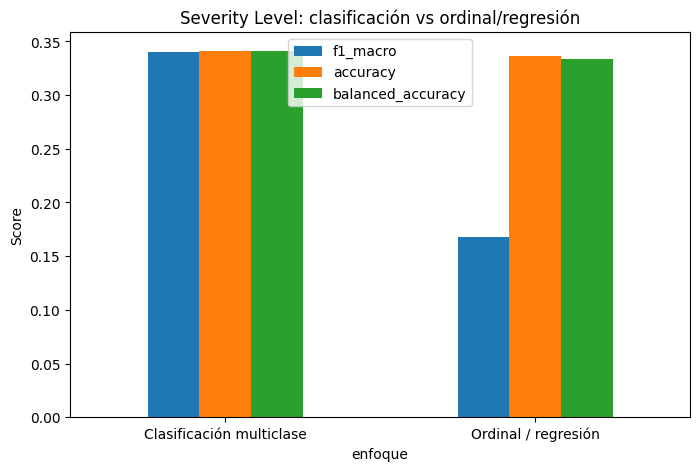

In [32]:
comparison_severity_modes.set_index("enfoque")[["f1_macro", "accuracy", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Severity Level: clasificación vs ordinal/regresión")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Interpretación del experimento ordinal / regresión

Los resultados muestran que tratar `Severity Level` como una variable ordinal y modelarla mediante regresión no mejora el enfoque de clasificación multiclase estándar.

Aunque la severidad presenta un orden natural (`Low < Medium < High`), la transformación a un problema de regresión y la posterior discretización de las predicciones provocan una pérdida clara de rendimiento, especialmente en **F1 macro**.

En concreto, la mejor formulación ordinal obtiene un **F1 macro de 0.1682**, muy por debajo del **0.3405** alcanzado por la mejor clasificación multiclase. Esto indica que, para este dataset, la formulación clásica de clasificación sigue siendo más adecuada para predecir `Severity Level`.

### Interpretación de los experimentos binarios

En los dos problemas binarios (`Blocked vs resto` y `High vs resto`), los modelos con mayor accuracy no son necesariamente los más útiles, ya que tienden a favorecer la clase mayoritaria.

En cambio, `Logistic Regression Balanced` obtiene el mejor F1-score en ambos casos, lo que sugiere que es el modelo que mejor consigue recuperar la clase positiva cuando el problema se formula como detección binaria.

## Experimento con texto: `Payload Data` usando TF-IDF

Hasta este punto del laboratorio, la mayor parte de los experimentos se han centrado en variables tabulares y transformaciones estructuradas del dataset.

Sin embargo, la columna `Payload Data` contiene texto libre y podría aportar señal adicional que no está siendo capturada por el pipeline tabular.

Como primer experimento, se utilizará únicamente `Payload Data`, vectorizada mediante **TF-IDF**, para entrenar modelos lineales y comprobar si el contenido textual por sí solo permite predecir mejor algunos targets del dataset.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import FunctionTransformer

In [34]:
def evaluate_text_target(df_raw, target_name, text_col="Payload Data", random_state=RANDOM_STATE):
    """
    Evalúa modelos de texto usando solo una columna textual vectorizada con TF-IDF.
    """

    all_targets = ["Action Taken", "Severity Level", "Attack Type"]
    y = df_raw[target_name].copy()
    X_text = df_raw[text_col].fillna("").astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X_text,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    models = {
        "Logistic Regression (TF-IDF)": LogisticRegression(max_iter=1000, random_state=random_state),
        "LinearSVC (TF-IDF)": LinearSVC(random_state=random_state),
        "Dummy": DummyClassifier(strategy="most_frequent", random_state=random_state),
    }

    results = {}
    trained_pipelines = {}

    for name, clf in models.items():
        if name == "Dummy":
            pipe = Pipeline([
                ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ("to_dense", FunctionTransformer(lambda x: x, accept_sparse=True)),
                ("classifier", clf),
            ])
        else:
            pipe = Pipeline([
                ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ("classifier", clf),
            ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X_test)
                roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
            except Exception:
                pass

        results[name] = {
            "target": target_name,
            "representation": "Payload Data (TF-IDF)",
            "model": name,
            "accuracy": round(acc, 4),
            "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4),
            "f1_macro": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4),
            "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan,
        }

        trained_pipelines[name] = pipe

    df_results = pd.DataFrame(results).T.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

    return df_results, trained_pipelines, X_train, X_test, y_train, y_test

## Experimento de texto A `Payload Data` para predecir `Action Taken`

En este experimento se utiliza únicamente el texto libre de `Payload Data`, transformado mediante TF-IDF, para comprobar si el contenido textual contiene señal suficiente para predecir la acción final tomada.

In [35]:
df_results_text_action, trained_text_action, X_train_text_action, X_test_text_action, y_train_text_action, y_test_text_action = evaluate_text_target(
    df,
    target_name="Action Taken",
    text_col="Payload Data"
)

df_results_text_action

,target,representation,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,Action Taken,Payload Data (TF-IDF),Logistic Regression (TF-IDF),0.3280,0.3282,0.3279,0.3278,0.3279,0.4946
1,Action Taken,Payload Data (TF-IDF),LinearSVC (TF-IDF),0.3277,0.3280,0.3277,0.3278,0.3277,NaN
2,Action Taken,Payload Data (TF-IDF),Dummy,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


In [36]:
best_model_text_action = df_results_text_action.iloc[0]["model"]
best_pipe_text_action = trained_text_action[best_model_text_action]
y_pred_text_action = best_pipe_text_action.predict(X_test_text_action)

print("Mejor modelo de texto para Action Taken:", best_model_text_action)
print("\nClassification report:\n")
print(classification_report(y_test_text_action, y_pred_text_action, zero_division=0))

Mejor modelo de texto para Action Taken: Logistic Regression (TF-IDF)

Classification report:

              precision    recall  f1-score   support

     Blocked       0.33      0.34      0.34      2706
     Ignored       0.32      0.33      0.32      2655
      Logged       0.34      0.31      0.32      2639

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



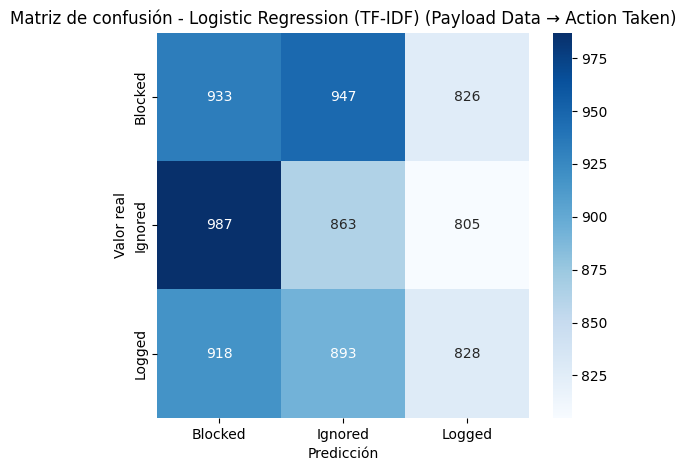

In [37]:
classes_action_text = sorted(y_test_text_action.unique())
cm_text_action = confusion_matrix(y_test_text_action, y_pred_text_action, labels=classes_action_text)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_text_action,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes_action_text,
    yticklabels=classes_action_text
)
plt.title(f"Matriz de confusión - {best_model_text_action} (Payload Data → Action Taken)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Experimento de texto B `Payload Data` para predecir `Attack Type`

En este segundo experimento se evalúa si `Payload Data` contiene señal suficiente para identificar el tipo de ataque directamente a partir del texto.

In [38]:
df_results_text_attack, trained_text_attack, X_train_text_attack, X_test_text_attack, y_train_text_attack, y_test_text_attack = evaluate_text_target(
    df,
    target_name="Attack Type",
    text_col="Payload Data"
)

df_results_text_attack

,target,representation,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,Attack Type,Payload Data (TF-IDF),LinearSVC (TF-IDF),0.3419,0.3421,0.3419,0.3419,0.3419,NaN
1,Attack Type,Payload Data (TF-IDF),Logistic Regression (TF-IDF),0.3417,0.3419,0.3418,0.3418,0.3418,0.5073
2,Attack Type,Payload Data (TF-IDF),Dummy,0.3357,0.1119,0.3333,0.1676,0.3333,0.5000


In [39]:
best_model_text_attack = df_results_text_attack.iloc[0]["model"]
best_pipe_text_attack = trained_text_attack[best_model_text_attack]
y_pred_text_attack = best_pipe_text_attack.predict(X_test_text_attack)

print("Mejor modelo de texto para Attack Type:", best_model_text_attack)
print("\nClassification report:\n")
print(classification_report(y_test_text_attack, y_pred_text_attack, zero_division=0))

Mejor modelo de texto para Attack Type: LinearSVC (TF-IDF)

Classification report:

              precision    recall  f1-score   support

        DDoS       0.33      0.34      0.34      2686
   Intrusion       0.34      0.35      0.34      2653
     Malware       0.35      0.34      0.35      2661

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



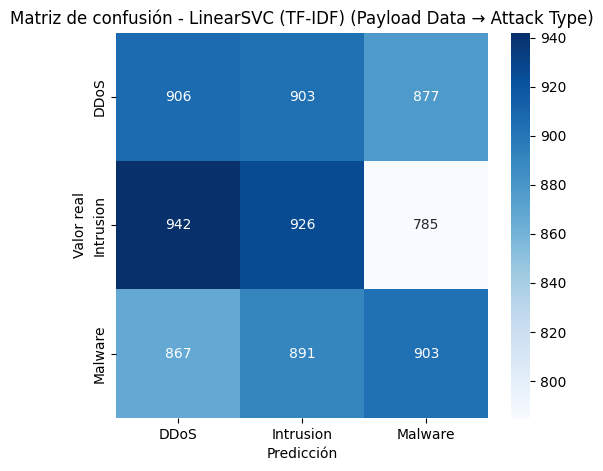

In [40]:
classes_attack_text = sorted(y_test_text_attack.unique())
cm_text_attack = confusion_matrix(y_test_text_attack, y_pred_text_attack, labels=classes_attack_text)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_text_attack,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes_attack_text,
    yticklabels=classes_attack_text
)
plt.title(f"Matriz de confusión - {best_model_text_attack} (Payload Data → Attack Type)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Comparación entre enfoque tabular y enfoque basado en texto

Una vez evaluado `Payload Data` con TF-IDF, se compara su rendimiento con el mejor resultado obtenido previamente mediante el pipeline tabular.

Esto permite determinar si el texto aporta una señal competitiva, complementaria o claramente inferior a la representación estructurada del dataset.

In [41]:
comparison_action_text_vs_tabular = pd.DataFrame([
    {
        "enfoque": "Tabular",
        "mejor_modelo": "XGBoost",
        "f1_macro": 0.3403,
        "accuracy": 0.3425,
        "balanced_accuracy": 0.3419
    },
    {
        "enfoque": "Texto (Payload Data)",
        "mejor_modelo": df_results_text_action.iloc[0]["model"],
        "f1_macro": df_results_text_action.iloc[0]["f1_macro"],
        "accuracy": df_results_text_action.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_text_action.iloc[0]["balanced_accuracy"]
    }
])

comparison_action_text_vs_tabular

,enfoque,mejor_modelo,f1_macro,accuracy,balanced_accuracy
0,Tabular,XGBoost,0.3403,0.3425,0.3419
1,Texto (Payload Data),Logistic Regression (TF-IDF),0.3278,0.3280,0.3279


In [42]:
comparison_attack_text_vs_tabular = pd.DataFrame([
    {
        "enfoque": "Tabular",
        "mejor_modelo": df_results_attack.iloc[0]["model"],
        "f1_macro": df_results_attack.iloc[0]["f1_macro"],
        "accuracy": df_results_attack.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_attack.iloc[0]["balanced_accuracy"]
    },
    {
        "enfoque": "Texto (Payload Data)",
        "mejor_modelo": df_results_text_attack.iloc[0]["model"],
        "f1_macro": df_results_text_attack.iloc[0]["f1_macro"],
        "accuracy": df_results_text_attack.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_text_attack.iloc[0]["balanced_accuracy"]
    }
])

comparison_attack_text_vs_tabular

,enfoque,mejor_modelo,f1_macro,accuracy,balanced_accuracy
0,Tabular,Random Forest,0.3410,0.3414,0.3413
1,Texto (Payload Data),LinearSVC (TF-IDF),0.3419,0.3419,0.3419


### Interpretación del experimento con texto (TF-IDF)

Los resultados muestran un comportamiento diferente según el target:

- Para **`Action Taken`**: el mejor modelo TF-IDF (Logistic Regression) obtiene F1 macro de 0.328, por debajo del pipeline tabular (0.340). El texto de
  `Payload Data` no aporta señal adicional para predecir la acción tomada.

- Para **`Attack Type`**: el mejor modelo TF-IDF (LinearSVC) obtiene F1 macro de 0.342, prácticamente igual al pipeline tabular (0.341). En este caso el
  contenido textual iguala al enfoque estructurado.

La conclusión más probable es que `Payload Data` contiene texto generado aleatoriamente (como sugiere que cada fila tenga un valor único), por lo que
TF-IDF no puede extraer patrones lingüísticos reales. Que iguale al tabular en `Attack Type` es probablemente coincidencia estadística, no señal textual real.


## Experimentos binarios sobre `Attack Type`

Como ampliación del laboratorio, se reformula ahora `Attack Type` en varios problemas binarios one-vs-rest:

- `DDoS` vs resto
- `Malware` vs resto
- `Intrusion` vs resto

El objetivo es comprobar si alguna de estas clases concretas se detecta mejor de forma aislada que en la formulación multiclase completa.

In [43]:
df_results_ddos, trained_ddos, X_train_ddos, X_test_ddos, y_train_ddos, y_test_ddos = evaluate_binary_target(
    df_model,
    original_target="Attack Type",
    positive_class="DDoS"
)

df_results_ddos

,target,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,Attack Type | DDoS vs resto,Logistic Regression Balanced,0.5028,0.3388,0.5056,0.4057,0.5035,0.5030
1,Attack Type | DDoS vs resto,ExtraTrees,0.6536,0.3144,0.0268,0.0494,0.4986,0.4948
2,Attack Type | DDoS vs resto,Random Forest,0.6619,0.3273,0.0067,0.0131,0.4999,0.5084
3,Attack Type | DDoS vs resto,Gradient Boosting,0.6641,0.4667,0.0026,0.0052,0.5006,0.5092
4,Attack Type | DDoS vs resto,Dummy,0.6643,0.0000,0.0000,0.0000,0.5000,0.5000
5,Attack Type | DDoS vs resto,Logistic Regression,0.6643,0.0000,0.0000,0.0000,0.5000,0.5029


In [44]:
best_model_ddos = df_results_ddos.iloc[0]["model"]
best_pipe_ddos = trained_ddos[best_model_ddos]
y_pred_ddos = best_pipe_ddos.predict(X_test_ddos)

print("Mejor modelo para DDoS vs resto:", best_model_ddos)
print("\nClassification report:\n")
print(classification_report(y_test_ddos, y_pred_ddos, zero_division=0))

Mejor modelo para DDoS vs resto: Logistic Regression Balanced

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.50      0.57      5314
           1       0.34      0.51      0.41      2686

    accuracy                           0.50      8000
   macro avg       0.50      0.50      0.49      8000
weighted avg       0.56      0.50      0.52      8000



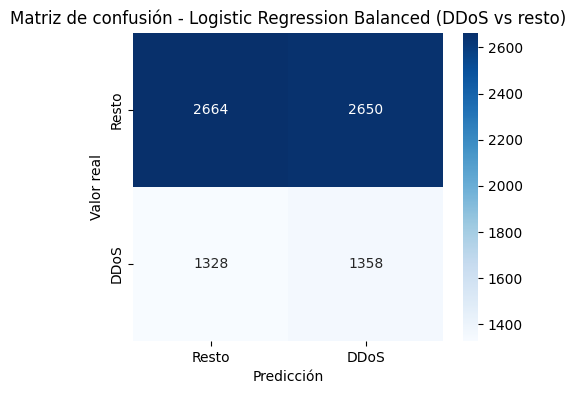

In [45]:
cm_ddos = confusion_matrix(y_test_ddos, y_pred_ddos)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_ddos,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Resto", "DDoS"],
    yticklabels=["Resto", "DDoS"]
)
plt.title(f"Matriz de confusión - {best_model_ddos} (DDoS vs resto)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [46]:
df_results_malware, trained_malware, X_train_malware, X_test_malware, y_train_malware, y_test_malware = evaluate_binary_target(
    df_model,
    original_target="Attack Type",
    positive_class="Malware"
)

df_results_malware

,target,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,Attack Type | Malware vs resto,Logistic Regression Balanced,0.5085,0.3400,0.5077,0.4073,0.5083,0.5112
1,Attack Type | Malware vs resto,ExtraTrees,0.6548,0.3150,0.0323,0.0586,0.4986,0.5040
2,Attack Type | Malware vs resto,Random Forest,0.6661,0.4074,0.0083,0.0162,0.5011,0.5026
3,Attack Type | Malware vs resto,Gradient Boosting,0.6676,0.5417,0.0049,0.0097,0.5014,0.5007
4,Attack Type | Malware vs resto,Dummy,0.6674,0.0000,0.0000,0.0000,0.5000,0.5000
5,Attack Type | Malware vs resto,Logistic Regression,0.6674,0.0000,0.0000,0.0000,0.5000,0.5112


In [47]:
best_model_malware = df_results_malware.iloc[0]["model"]
best_pipe_malware = trained_malware[best_model_malware]
y_pred_malware = best_pipe_malware.predict(X_test_malware)

print("Mejor modelo para Malware vs resto:", best_model_malware)
print("\nClassification report:\n")
print(classification_report(y_test_malware, y_pred_malware, zero_division=0))

Mejor modelo para Malware vs resto: Logistic Regression Balanced

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.51      0.58      5339
           1       0.34      0.51      0.41      2661

    accuracy                           0.51      8000
   macro avg       0.51      0.51      0.49      8000
weighted avg       0.56      0.51      0.52      8000



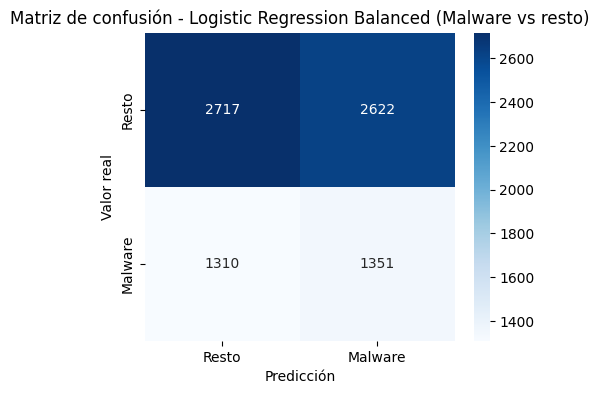

In [48]:
cm_malware = confusion_matrix(y_test_malware, y_pred_malware)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_malware,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Resto", "Malware"],
    yticklabels=["Resto", "Malware"]
)
plt.title(f"Matriz de confusión - {best_model_malware} (Malware vs resto)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [49]:
df_results_intrusion, trained_intrusion, X_train_intrusion, X_test_intrusion, y_train_intrusion, y_test_intrusion = evaluate_binary_target(
    df_model,
    original_target="Attack Type",
    positive_class="Intrusion"
)

df_results_intrusion

,target,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,Attack Type | Intrusion vs resto,Logistic Regression Balanced,0.5052,0.3338,0.4938,0.3983,0.5024,0.5026
1,Attack Type | Intrusion vs resto,ExtraTrees,0.6559,0.3077,0.0302,0.0549,0.4982,0.4937
2,Attack Type | Intrusion vs resto,Random Forest,0.6654,0.1667,0.0023,0.0045,0.4983,0.5012
3,Attack Type | Intrusion vs resto,Gradient Boosting,0.6683,0.3333,0.0004,0.0008,0.5000,0.5046
4,Attack Type | Intrusion vs resto,Dummy,0.6684,0.0000,0.0000,0.0000,0.5000,0.5000
5,Attack Type | Intrusion vs resto,Logistic Regression,0.6684,0.0000,0.0000,0.0000,0.5000,0.5028


In [50]:
best_model_intrusion = df_results_intrusion.iloc[0]["model"]
best_pipe_intrusion = trained_intrusion[best_model_intrusion]
y_pred_intrusion = best_pipe_intrusion.predict(X_test_intrusion)

print("Mejor modelo para Intrusion vs resto:", best_model_intrusion)
print("\nClassification report:\n")
print(classification_report(y_test_intrusion, y_pred_intrusion, zero_division=0))

Mejor modelo para Intrusion vs resto: Logistic Regression Balanced

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.51      0.58      5347
           1       0.33      0.49      0.40      2653

    accuracy                           0.51      8000
   macro avg       0.50      0.50      0.49      8000
weighted avg       0.56      0.51      0.52      8000



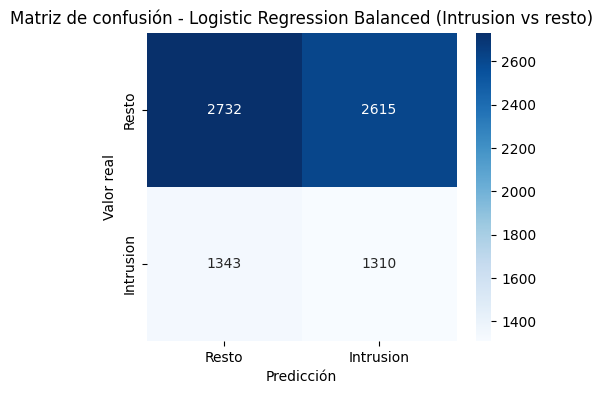

In [51]:
cm_intrusion = confusion_matrix(y_test_intrusion, y_pred_intrusion)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_intrusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Resto", "Intrusion"],
    yticklabels=["Resto", "Intrusion"]
)
plt.title(f"Matriz de confusión - {best_model_intrusion} (Intrusion vs resto)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Comparación de formulaciones binarias para `Attack Type`

Una vez evaluadas las tres variantes binarias, se comparan sus mejores resultados para identificar si alguna clase concreta resulta más detectable que las demás.

In [52]:
comparison_attack_binary = pd.DataFrame([
    {
        "experimento": "DDoS vs resto",
        "mejor_modelo": df_results_ddos.iloc[0]["model"],
        "f1": df_results_ddos.iloc[0]["f1"],
        "accuracy": df_results_ddos.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_ddos.iloc[0]["balanced_accuracy"],
        "roc_auc": df_results_ddos.iloc[0]["roc_auc"]
    },
    {
        "experimento": "Malware vs resto",
        "mejor_modelo": df_results_malware.iloc[0]["model"],
        "f1": df_results_malware.iloc[0]["f1"],
        "accuracy": df_results_malware.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_malware.iloc[0]["balanced_accuracy"],
        "roc_auc": df_results_malware.iloc[0]["roc_auc"]
    },
    {
        "experimento": "Intrusion vs resto",
        "mejor_modelo": df_results_intrusion.iloc[0]["model"],
        "f1": df_results_intrusion.iloc[0]["f1"],
        "accuracy": df_results_intrusion.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_intrusion.iloc[0]["balanced_accuracy"],
        "roc_auc": df_results_intrusion.iloc[0]["roc_auc"]
    }
])

comparison_attack_binary

,experimento,mejor_modelo,f1,accuracy,balanced_accuracy,roc_auc
0,DDoS vs resto,Logistic Regression Balanced,0.4057,0.5028,0.5035,0.5030
1,Malware vs resto,Logistic Regression Balanced,0.4073,0.5085,0.5083,0.5112
2,Intrusion vs resto,Logistic Regression Balanced,0.3983,0.5052,0.5024,0.5026


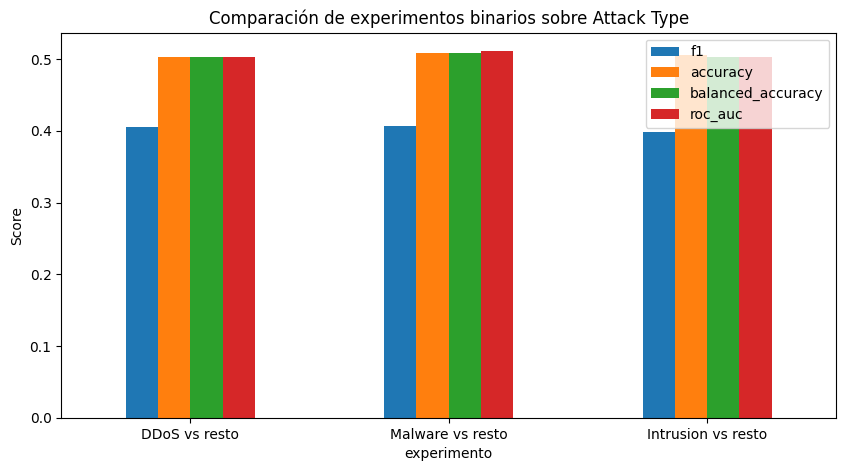

In [53]:
comparison_attack_binary.set_index("experimento")[["f1", "accuracy", "balanced_accuracy", "roc_auc"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Comparación de experimentos binarios sobre Attack Type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [54]:
best_model_attack_multiclass = df_results_attack.iloc[0]["model"]
best_pipe_attack_multiclass = trained_attack[best_model_attack_multiclass]
y_pred_attack_multiclass = best_pipe_attack_multiclass.predict(X_test_att)

errors_attack = X_test_att.copy()
errors_attack["y_true"] = y_test_att.values
errors_attack["y_pred"] = y_pred_attack_multiclass

errors_only_attack = errors_attack[errors_attack["y_true"] != errors_attack["y_pred"]].copy()
errors_only_attack.head(10)

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Anomaly Scores,Attack Signature,Network Segment,Log Source,hour,day,month,dayofweek,is_weekend,part_of_day,Source Port Range,Destination Port Range,Destination Port Group,Malware Indicators_present,Alerts/Warnings_present,Firewall Logs_present,IDS/IPS Alerts_present,Proxy Information_present,y_true,y_pred
15937,45046,9436,TCP,1381,Data,DNS,77.7200,Known Pattern A,Segment C,Server,15,4,3,3,0,tarde,registered,registered,other,0,0,0,0,0,Malware,Intrusion
17942,57768,32789,ICMP,169,Control,HTTP,10.5000,Known Pattern B,Segment C,Server,16,2,1,0,0,tarde,dynamic,registered,other,1,0,0,0,1,Intrusion,Malware
24645,46820,11681,UDP,513,Data,FTP,23.5300,Known Pattern B,Segment B,Firewall,5,23,10,5,1,madrugada,registered,registered,other,0,0,0,1,1,Intrusion,Malware
31892,49081,31196,TCP,1116,Data,FTP,20.4300,Known Pattern A,Segment A,Server,18,18,8,2,0,noche,registered,registered,other,0,0,1,1,1,Intrusion,DDoS
24058,14825,55399,ICMP,1145,Data,FTP,88.7700,Known Pattern A,Segment C,Firewall,2,24,11,2,0,madrugada,registered,dynamic,other,1,1,0,0,0,DDoS,Malware
28161,43345,52084,TCP,1300,Control,FTP,87.2300,Known Pattern A,Segment C,Server,15,2,5,0,0,tarde,registered,dynamic,other,0,0,0,0,0,Malware,Intrusion
20999,14646,4639,UDP,97,Data,DNS,80.3300,Known Pattern A,Segment C,Server,19,6,4,0,0,noche,registered,registered,other,0,1,0,0,1,Malware,DDoS
28102,25605,33823,ICMP,832,Control,HTTP,23.7400,Known Pattern A,Segment A,Server,5,5,1,6,1,madrugada,registered,registered,other,1,0,0,1,1,Malware,Intrusion
24413,41693,1128,TCP,933,Data,FTP,77.2700,Known Pattern B,Segment C,Firewall,13,26,2,6,1,tarde,registered,registered,other,1,0,0,1,0,Intrusion,Malware
33341,44390,26166,TCP,476,Control,DNS,79.0300,Known Pattern B,Segment A,Firewall,7,20,9,6,1,mañana,registered,registered,other,1,1,1,0,1,Malware,Intrusion


In [55]:
error_pairs = (
    errors_only_attack.groupby(["y_true", "y_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs.head(10)

,y_true,y_pred,count
2,Intrusion,DDoS,964
4,Malware,DDoS,920
5,Malware,Intrusion,911
0,DDoS,Intrusion,881
1,DDoS,Malware,823
3,Intrusion,Malware,770


In [56]:
errors_only_attack[["Source Port", "Destination Port", "Packet Length", "Anomaly Scores"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Source Port,5269.0000,33385.2536,18476.1095,1031.0000,17247.0000,33728.0000,48977.0000,65507.0000
Destination Port,5269.0000,32887.1143,18696.7157,1028.0000,16647.0000,32760.0000,49421.0000,65511.0000
Packet Length,5269.0000,770.5126,416.2616,64.0000,410.0000,763.0000,1133.0000,1500.0000
Anomaly Scores,5269.0000,49.8068,29.0867,0.0000,24.3900,49.6600,75.2900,99.9900


In [57]:
cols_to_show = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Network Segment",
    "Log Source",
    "Attack Signature",
    "Source Port",
    "Destination Port",
    "Packet Length",
    "Anomaly Scores",
    "Destination Port Group",
    "y_true",
    "y_pred"
]

errors_only_attack[cols_to_show].head(15)

,Protocol,Packet Type,Traffic Type,Network Segment,Log Source,Attack Signature,Source Port,Destination Port,Packet Length,Anomaly Scores,Destination Port Group,y_true,y_pred
15937,TCP,Data,DNS,Segment C,Server,Known Pattern A,45046,9436,1381,77.7200,other,Malware,Intrusion
17942,ICMP,Control,HTTP,Segment C,Server,Known Pattern B,57768,32789,169,10.5000,other,Intrusion,Malware
24645,UDP,Data,FTP,Segment B,Firewall,Known Pattern B,46820,11681,513,23.5300,other,Intrusion,Malware
31892,TCP,Data,FTP,Segment A,Server,Known Pattern A,49081,31196,1116,20.4300,other,Intrusion,DDoS
24058,ICMP,Data,FTP,Segment C,Firewall,Known Pattern A,14825,55399,1145,88.7700,other,DDoS,Malware
28161,TCP,Control,FTP,Segment C,Server,Known Pattern A,43345,52084,1300,87.2300,other,Malware,Intrusion
20999,UDP,Data,DNS,Segment C,Server,Known Pattern A,14646,4639,97,80.3300,other,Malware,DDoS
28102,ICMP,Control,HTTP,Segment A,Server,Known Pattern A,25605,33823,832,23.7400,other,Malware,Intrusion
24413,TCP,Data,FTP,Segment C,Firewall,Known Pattern B,41693,1128,933,77.2700,other,Intrusion,Malware
33341,TCP,Control,DNS,Segment A,Firewall,Known Pattern B,44390,26166,476,79.0300,other,Malware,Intrusion


### Interpretación del análisis de errores

Los seis pares de confusión posibles (entre tres clases) se distribuyen de forma relativamente uniforme: el par más confundido es Intrusion→DDoS (964 casos),
seguido de Malware→DDoS (920), Malware→Intrusion (911), DDoS→Intrusion (881), DDoS→Malware (823) e Intrusion→Malware (770).

DDoS tiende a absorber ligeramente más errores como predicción incorrecta, pero la diferencia es pequeña. No hay un par dominante que sugiera confusión
estructural entre clases concretas.

Las estadísticas descriptivas de los errores muestran distribuciones de variables (puertos, Packet Length, Anomaly Scores) prácticamente idénticas a las del dataset
completo. Esto confirma que el modelo no falla en un subconjunto específico de condiciones de red, sino de forma aleatoria y uniforme — coherente con la ausencia
de señal predictiva real en el dataset.

## Tuneo de árboles: control de complejidad en Random Forest

Como parte final del laboratorio, se estudia cómo afectan algunos hiperparámetros clásicos de los árboles de decisión al rendimiento del modelo.

En particular, se analizan:

- `max_depth`
- `min_samples_leaf`
- `min_samples_split`

El objetivo no es realizar una búsqueda exhaustiva, sino observar de forma controlada cómo cambia el comportamiento del modelo al limitar o flexibilizar la complejidad de los árboles.

In [58]:
def evaluate_rf_configs_attack_type(df_variant, configs, random_state=RANDOM_STATE):
    """
    Evalúa varias configuraciones de RandomForestClassifier sobre Attack Type.
    """
    X = df_variant.drop(columns=["Action Taken", "Severity Level", "Attack Type"])
    y = df_variant["Attack Type"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    num_cols_local = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_local = X_train.select_dtypes(include=["object"]).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    results = []
    trained_pipelines = {}

    for cfg_name, cfg in configs.items():
        clf = RandomForestClassifier(
            n_estimators=100,
            random_state=random_state,
            **cfg
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", clf),
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        results.append({
            "config": cfg_name,
            "accuracy": round(acc, 4),
            "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4),
            "f1_macro": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4),
            "max_depth": cfg.get("max_depth", None),
            "min_samples_leaf": cfg.get("min_samples_leaf", 1),
            "min_samples_split": cfg.get("min_samples_split", 2),
            "criterion": cfg.get("criterion", "gini"),
        })

        trained_pipelines[cfg_name] = pipe

    df_results = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

    return df_results, trained_pipelines

In [59]:
rf_depth_configs = {
    "depth_3": {"max_depth": 3},
    "depth_5": {"max_depth": 5},
    "depth_10": {"max_depth": 10},
    "depth_None": {"max_depth": None},
}

df_rf_depth, trained_rf_depth = evaluate_rf_configs_attack_type(df_model, rf_depth_configs)
df_rf_depth

,config,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,max_depth,min_samples_leaf,min_samples_split,criterion
0,depth_10,0.3431,0.3427,0.3430,0.3423,0.3430,10.0000,1,2,gini
1,depth_None,0.3414,0.3414,0.3413,0.3410,0.3413,NaN,1,2,gini
2,depth_5,0.3451,0.3454,0.3447,0.3407,0.3447,5.0000,1,2,gini
3,depth_3,0.3356,0.3344,0.3348,0.3195,0.3348,3.0000,1,2,gini


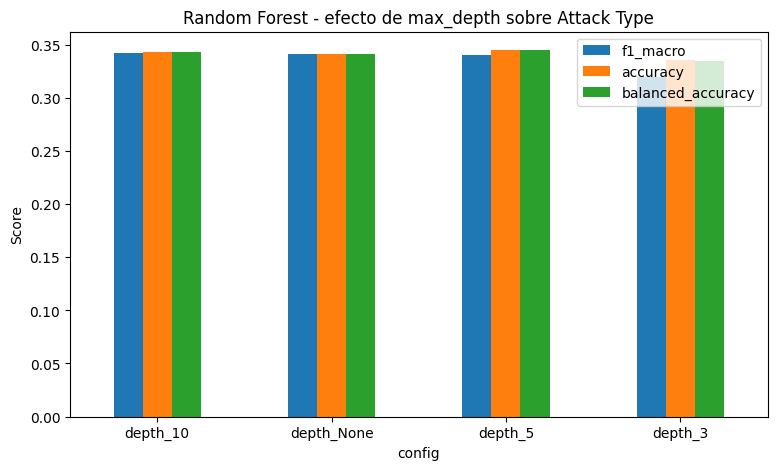

In [60]:
df_rf_depth.set_index("config")[["f1_macro", "accuracy", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Random Forest - efecto de max_depth sobre Attack Type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [61]:
rf_leaf_configs = {
    "leaf_1": {"min_samples_leaf": 1},
    "leaf_5": {"min_samples_leaf": 5},
    "leaf_10": {"min_samples_leaf": 10},
    "leaf_20": {"min_samples_leaf": 20},
}

df_rf_leaf, trained_rf_leaf = evaluate_rf_configs_attack_type(df_model, rf_leaf_configs)
df_rf_leaf

,config,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,max_depth,min_samples_leaf,min_samples_split,criterion
0,leaf_1,0.3414,0.3414,0.3413,0.3410,0.3413,None,1,2,gini
1,leaf_20,0.3407,0.3405,0.3406,0.3404,0.3406,None,20,2,gini
2,leaf_5,0.3376,0.3376,0.3376,0.3375,0.3376,None,5,2,gini
3,leaf_10,0.3339,0.3340,0.3338,0.3337,0.3338,None,10,2,gini


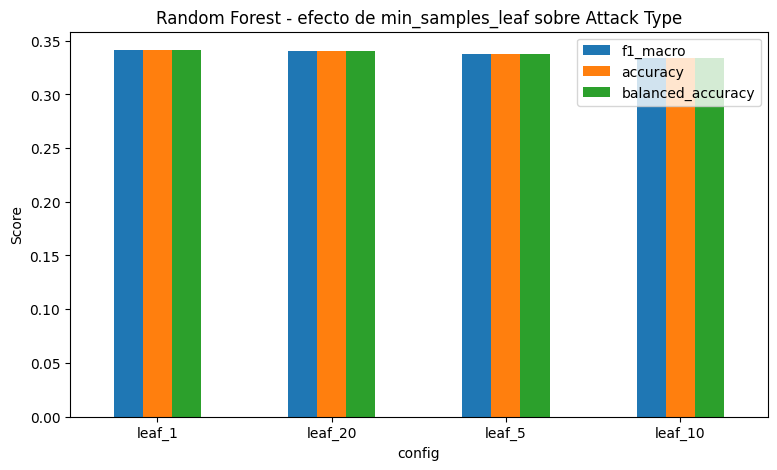

In [62]:
df_rf_leaf.set_index("config")[["f1_macro", "accuracy", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Random Forest - efecto de min_samples_leaf sobre Attack Type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [63]:
rf_split_configs = {
    "split_2": {"min_samples_split": 2},
    "split_5": {"min_samples_split": 5},
    "split_10": {"min_samples_split": 10},
    "split_20": {"min_samples_split": 20},
}

df_rf_split, trained_rf_split = evaluate_rf_configs_attack_type(df_model, rf_split_configs)
df_rf_split

,config,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,max_depth,min_samples_leaf,min_samples_split,criterion
0,split_2,0.3414,0.3414,0.3413,0.3410,0.3413,None,1,2,gini
1,split_10,0.3356,0.3356,0.3356,0.3356,0.3356,None,1,10,gini
2,split_20,0.3355,0.3353,0.3354,0.3353,0.3354,None,1,20,gini
3,split_5,0.3282,0.3283,0.3282,0.3282,0.3282,None,1,5,gini


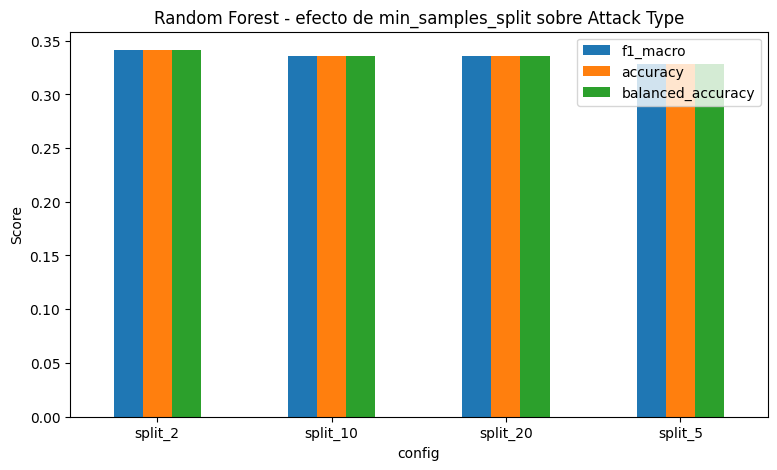

In [64]:
df_rf_split.set_index("config")[["f1_macro", "accuracy", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Random Forest - efecto de min_samples_split sobre Attack Type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [65]:
best_depth = df_rf_depth.iloc[0].copy()
best_leaf = df_rf_leaf.iloc[0].copy()
best_split = df_rf_split.iloc[0].copy()

rf_tuning_summary = pd.DataFrame([
    {
        "grupo": "max_depth",
        "mejor_config": best_depth["config"],
        "f1_macro": best_depth["f1_macro"],
        "accuracy": best_depth["accuracy"],
        "balanced_accuracy": best_depth["balanced_accuracy"]
    },
    {
        "grupo": "min_samples_leaf",
        "mejor_config": best_leaf["config"],
        "f1_macro": best_leaf["f1_macro"],
        "accuracy": best_leaf["accuracy"],
        "balanced_accuracy": best_leaf["balanced_accuracy"]
    },
    {
        "grupo": "min_samples_split",
        "mejor_config": best_split["config"],
        "f1_macro": best_split["f1_macro"],
        "accuracy": best_split["accuracy"],
        "balanced_accuracy": best_split["balanced_accuracy"]
    }
])

rf_tuning_summary

,grupo,mejor_config,f1_macro,accuracy,balanced_accuracy
0,max_depth,depth_10,0.3423,0.3431,0.3430
1,min_samples_leaf,leaf_1,0.3410,0.3414,0.3413
2,min_samples_split,split_2,0.3410,0.3414,0.3413


### Interpretación del tuneo de árboles

Este bloque permite observar si limitar la complejidad de los árboles mejora la capacidad de generalización del modelo o, por el contrario, reduce demasiado su flexibilidad.

Si configuraciones con menor profundidad o con hojas más grandes igualan o superan al modelo por defecto, eso sugeriría que el árbol original estaba sobredimensionado para la señal disponible en el dataset.  

Pero, como se puede ver no se observan mejoras claras, reforzando la idea de que el principal límite no está en la complejidad del modelo, sino en la información contenida en las variables.

## Conclusión del Notebook 2 (ayudado en parte por IA)

### Resumen del trabajo realizado

En este notebook se ha extendido el trabajo del notebook 1 aplicando el mismo pipeline de preprocesado y modelado a los otros dos targets del dataset: `Severity Level` y
`Attack Type`. Además se han explorado varias líneas de experimentación adicionales:

- análisis de importancia de variables mediante Random Forest,
- reformulación binaria de los tres targets (one-vs-rest),
- formulación ordinal de `Severity Level` mediante regresión,
- uso de `Payload Data` como feature textual con TF-IDF,
- experimentos binarios sobre las tres clases de `Attack Type`,
- análisis de errores del mejor modelo multiclase,
- y tuneo de hiperparámetros de Random Forest.

### Resultados globales de los tres targets

| Target | Mejor modelo | F1 macro | Accuracy |
|---|---|---:|---:|
| Action Taken | XGBoost | 0.3403 | 0.3425 |
| Severity Level | Logistic Regression | 0.3405 | 0.3415 |
| Attack Type | Random Forest | 0.3410 | 0.3414 |

Los tres targets obtienen resultados prácticamente idénticos. Ninguno resulta significativamente más predecible que los demás, lo que confirma que la señal
predictiva del dataset es limitada de forma generalizada e independiente del target.

### Hallazgos principales

**Importancia de variables:** las cuatro numéricas continuas (`Anomaly Scores`,`Source Port`, `Destination Port`, `Packet Length`) lideran el ranking en ambos
targets con importancias casi idénticas entre sí (~0.096). No hay ninguna variable dominante, lo que indica que el modelo distribuye su capacidad predictiva de forma
difusa sin encontrar un predictor clave.

**Reformulación binaria:** simplificar el problema a dos clases permite que `Logistic Regression Balanced` alcance F1 de ~0.40–0.42, mejorando el ~0.33
multiclase. Sin embargo, esta mejora se explica por el ajuste del balance de clases, no por mayor señal en los datos. El resto de modelos colapsan sobre la clase
mayoritaria con F1 cercano a cero.

**Formulación ordinal:** tratar `Severity Level` como variable ordinal y modelarla con regresión obtiene F1 macro de 0.168, equivalente a un Dummy. La estructura
ordenada del target no aporta ventaja en este dataset.

**Experimento TF-IDF:** `Payload Data` vectorizado con TF-IDF iguala al pipeline tabular en `Attack Type` (F1 0.342 vs 0.341) pero queda por debajo en `Action Taken`
(F1 0.328 vs 0.340). Dado que cada fila de `Payload Data` tiene un valor único en el dataset, la señal extraída por TF-IDF es probablemente ruido estadístico, no
patrones textuales reales.

**Tuneo de hiperparámetros:** limitar la profundidad o aumentar el tamaño mínimo de hoja en Random Forest no mejora el rendimiento de forma consistente. El mejor
resultado sigue siendo comparable al modelo con parámetros por defecto, lo que confirma que el límite no está en la complejidad del modelo sino en la señal
disponible en los datos.

**Análisis de errores:** los seis pares de confusión posibles entre las tres clases de `Attack Type` se distribuyen de forma uniforme, sin ningún par dominante. Las
características numéricas de los ejemplos mal clasificados son prácticamente idénticas a las del dataset completo, lo que indica que el modelo falla de forma
aleatoria y no en condiciones específicas de red.

### Conclusión global de la práctica

A lo largo de los dos notebooks se ha abordado la predicción de los tres targets del dataset de ciberseguridad siguiendo una metodología completa: EDA, preprocesado
justificado, pipeline con varios modelos, validación cruzada, feature engineering iterativo y múltiples experimentos de reformulación del problema.

El rendimiento máximo alcanzado ronda el 0.34 de F1 macro en clasificación multiclase, el 0.42 en formulación binaria con balance de clases, y el 0.17 en
formulación ordinal. Estos valores son coherentes con un dataset donde los targets han sido asignados de forma sintética e independiente de las variables de red
disponibles.

El valor de este trabajo reside en que se han explorado múltiples enfoques de forma razonada, y que considero que se han identificado las limitaciones del dataset, que es precisamente lo que el enunciado de la práctica me da a entender.